# Blind Source Separation using ICA and PCA

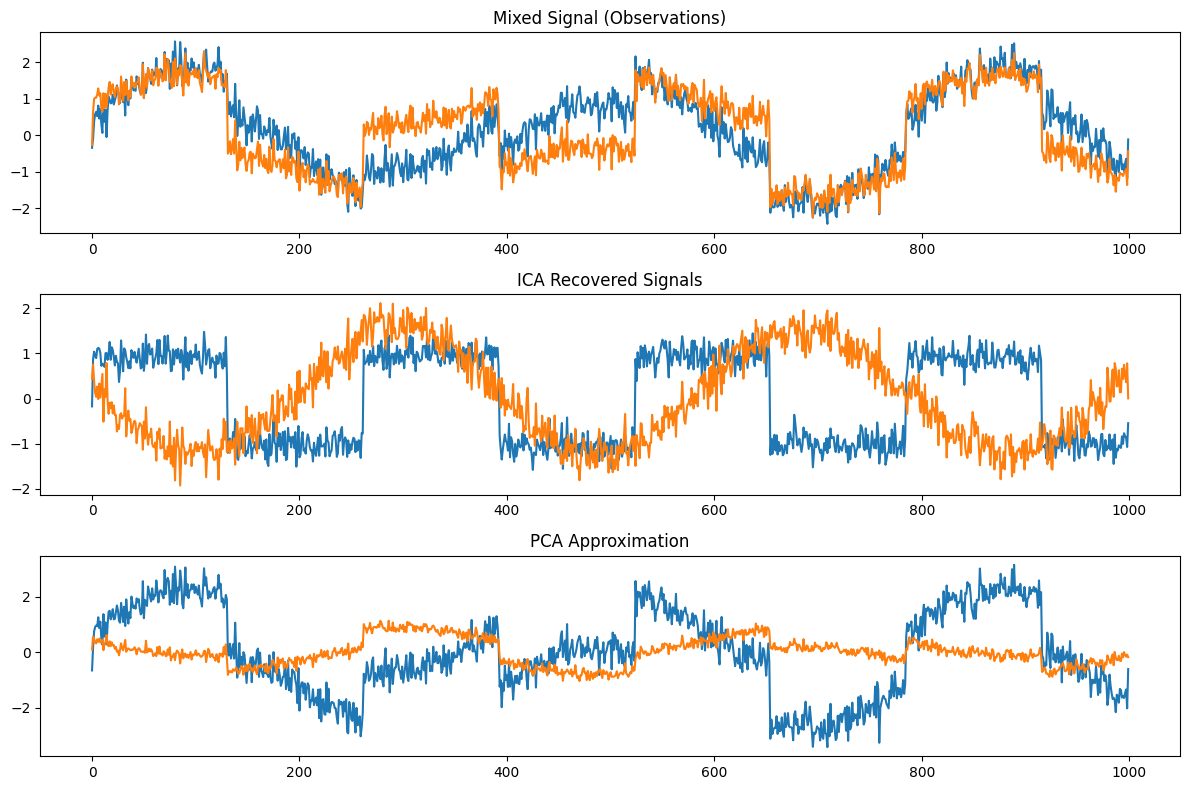

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import FastICA, PCA

# Simulate two source signals
fs = 1000
t = np.linspace(0, 8, fs)
s1 = np.sin(2 * t)
s2 = np.sign(np.sin(3 * t))
S = np.c_[s1, s2]
S += 0.2 * np.random.normal(size=S.shape)
S /= S.std(axis=0)

# Mix the sources
A = np.array([[1, 0.5], [0.5, 1]])
X = S @ A.T

# Apply ICA
ica = FastICA(n_components=2)
S_ica = ica.fit_transform(X)

# Apply PCA
pca = PCA(n_components=2)
S_pca = pca.fit_transform(X)

# Plot
plt.figure(figsize=(12, 8))
models = [X, S_ica, S_pca]
names = ['Mixed Signal (Observations)', 'ICA Recovered Signals', 'PCA Approximation']
for i, (model, name) in enumerate(zip(models, names), 1):
    plt.subplot(3, 1, i)
    plt.plot(model)
    plt.title(name)
plt.tight_layout()
plt.show()